The input dataset we used for our research was a dataset which intergrated the research publication data from 6 IRIS institutions with the index and meta data from Open Citation.

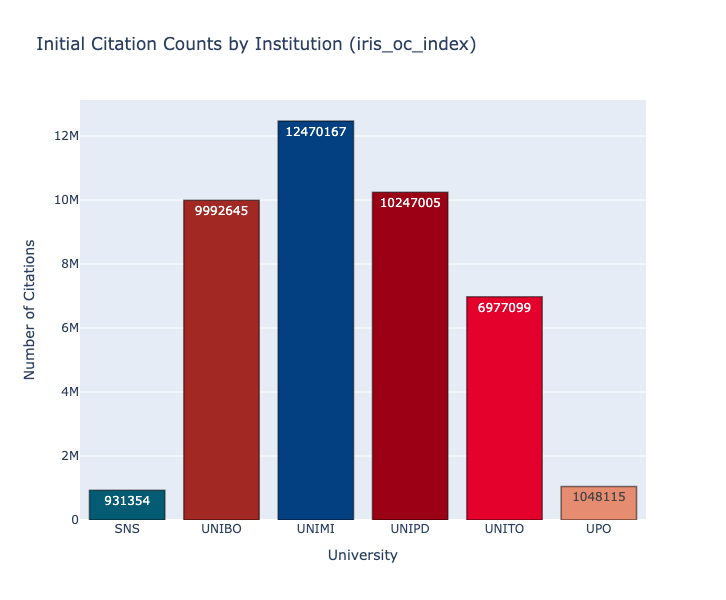

In [ ]:
import json
import plotly.graph_objects as go

# Load the JSON data
with open('bloom/disciplinary_flow/iris_data_summary.json', 'r') as f:
    data = json.load(f)

# University colors
uni_colors = {
    "SNS": "035B74",
    "UNIBO": "A22823",
    "UNIMI": "034082",
    "UNIPD": "9C0014",
    "UNITO": "E4022D",
    "UPO": "E58C71"
}

# Extract university names and iris_oc_index values
universities = [item['university'] for item in data]
iris_counts = [item['iris_oc_index'] for item in data]
bar_colors = [f"#{uni_colors[uni]}" for uni in universities]

# Create bar chart
fig = go.Figure(data=[
    go.Bar(
        x=universities,
        y=iris_counts,
        text=iris_counts,
        textposition='auto',
        marker=dict(
            color=bar_colors,
            line=dict(color='rgba(0, 0, 0, 0.5)', width=1.5)
        )
    )
])

fig.update_layout(
    title="Initial Citation Counts by Institution (iris_oc_index)",
    xaxis_title="University",
    yaxis_title="Number of Citations",
    font=dict(size=12),
    height=600,
    width=1000,
    hovermode='x unified'
)

fig.show()

Because we were interested in investigating the flow of disciplines between citations we focused on the data from OpenCitations index, which lists each citation made from every publication from each institution. The number of citations per institution varied greatly with UNIMI having over 12 million citations while SNS contained less than 1 million citations.

During the processing of the data we wanted to work with only those rows containing all the information we needed. This meant that at every step of the process we sectioned of the data that was usable (which we could match with external datasets and classify with LOC subject headings) from the data that was not usable (where no match could be made). This means that for our final analysis, the data we were not working the population but only with the data most meaningful for our investigation.

For future work it would be good to find away to resolve as much of the missing data as possible to see if this woudl have a bearing on our findings.  

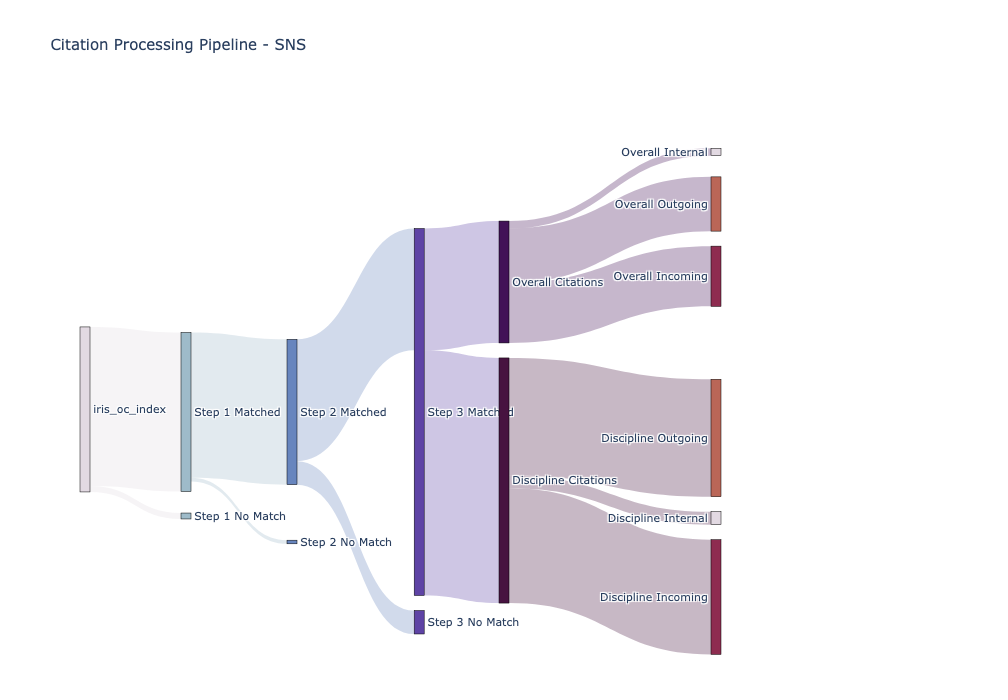

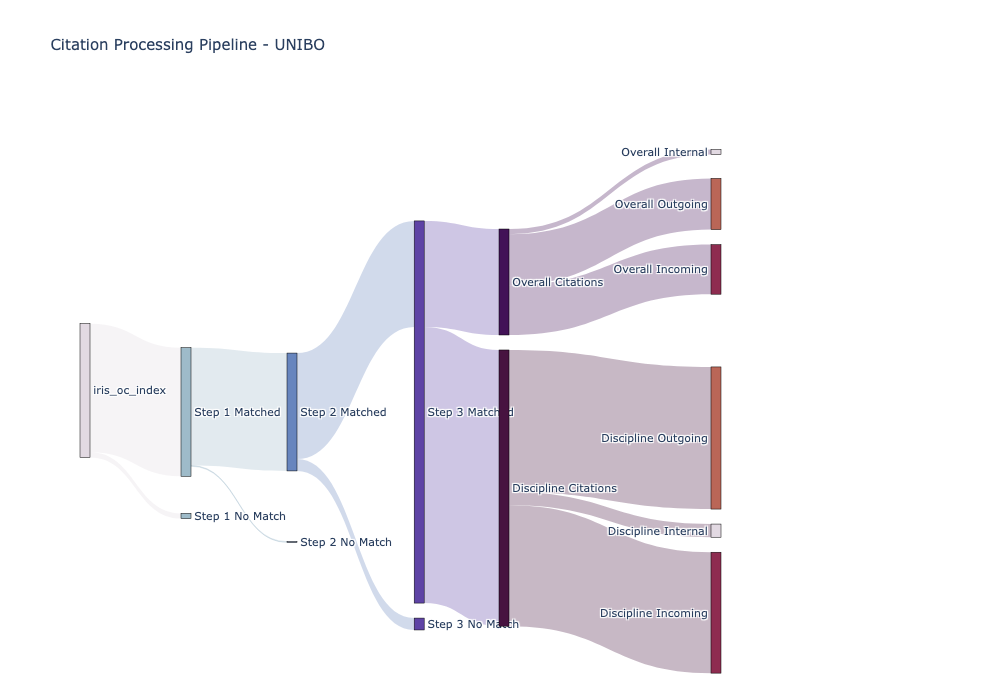

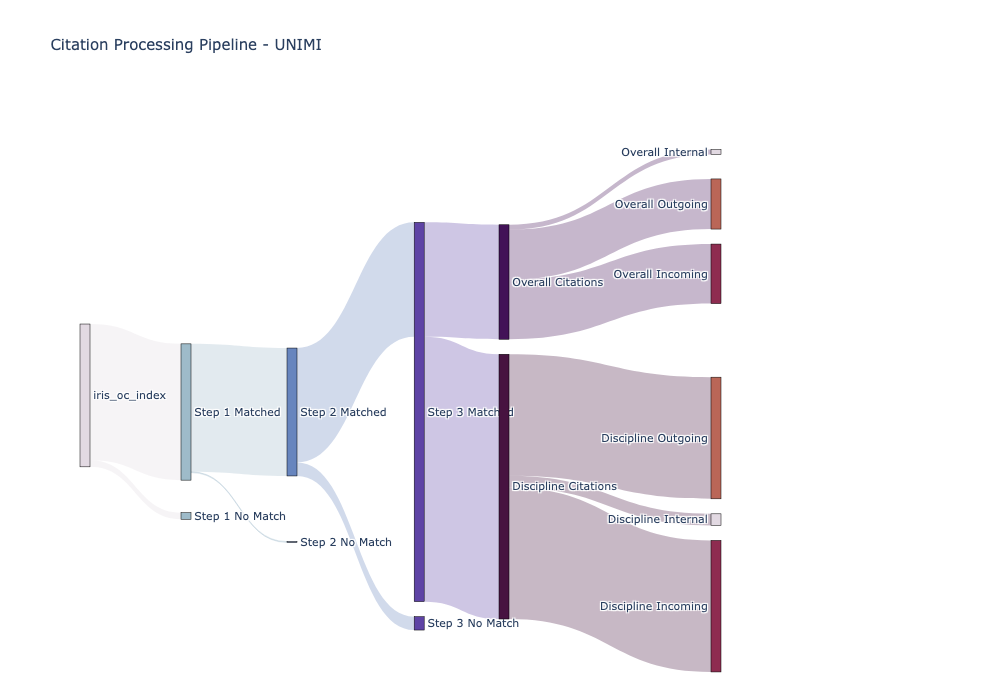

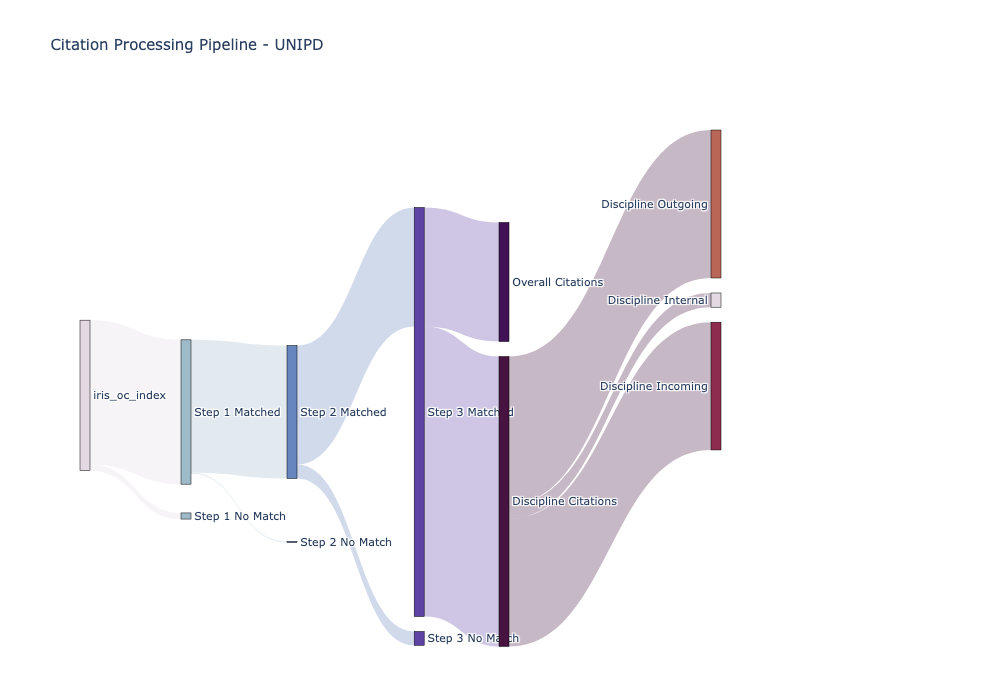

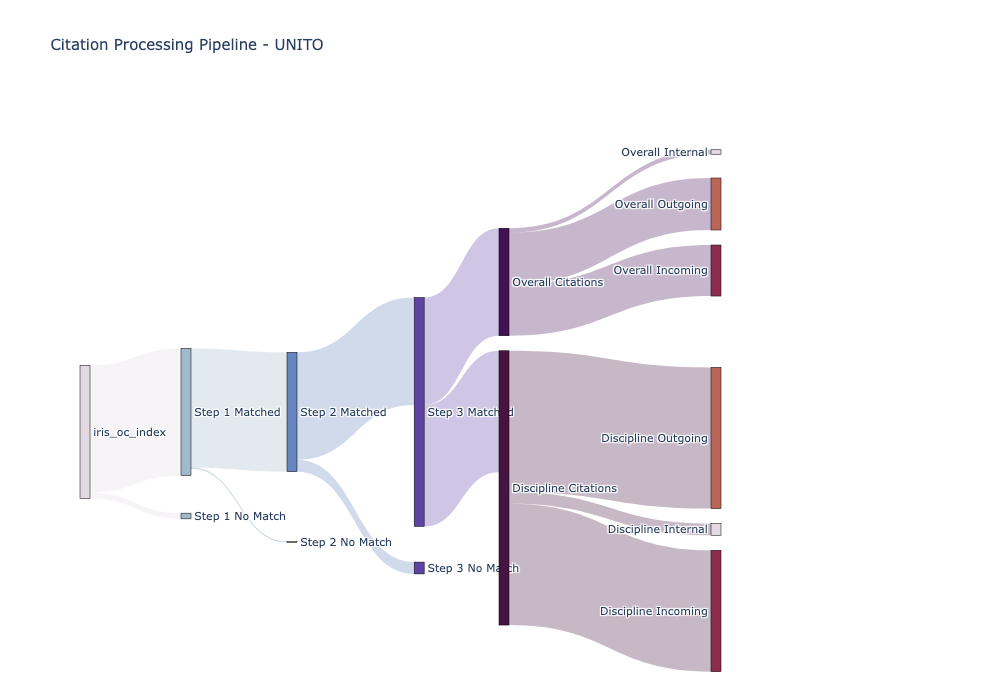

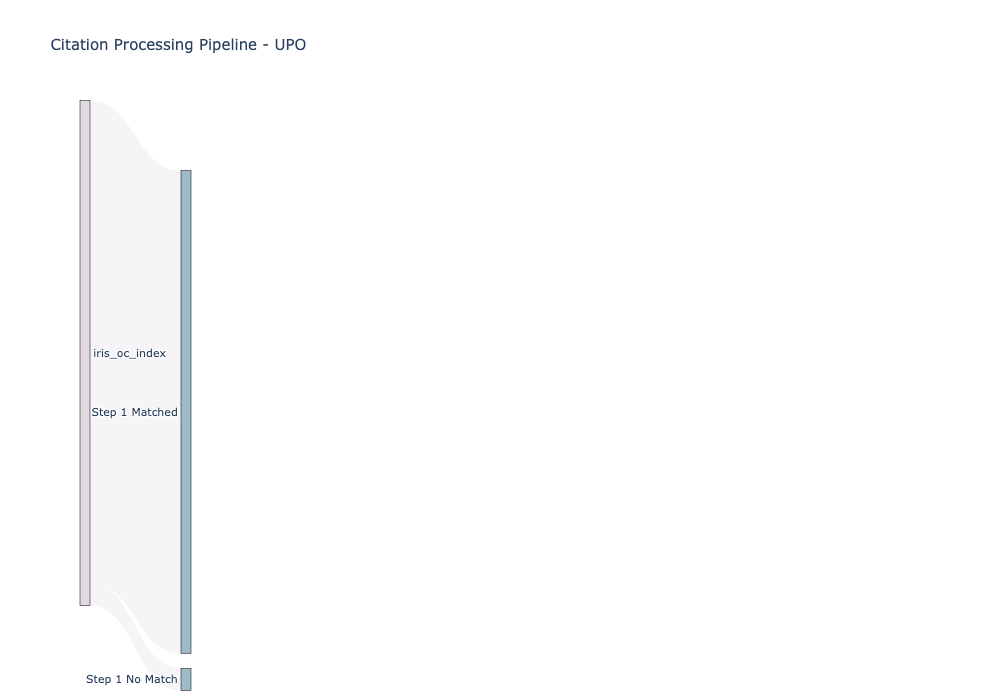

In [41]:
import json
import plotly.graph_objects as go
import plotly.express as px

# Load the JSON data
with open('/Users/regina/Documents/UNIBO/OpenScience/2025-2026/bloom/disciplinary_flow/iris_data_summary.json', 'r') as f:
    data = json.load(f)

def create_sankey_diagram(university_data):
    """
    Creates a Sankey diagram for a single institution showing:
    Step 1-3 processing pipeline with matched/no match splits,
    and final output split by flow type.
    """
    university = university_data['university']
    
    # Extract data from each step
    step1 = university_data['step 1']
    step2 = university_data['step 2']
    step3 = university_data['step 3']
    final = university_data['final output']
    
    nodes = [
        "iris_oc_index",
        "Step 1 Matched",
        "Step 1 No Match",
        "Step 2 Matched",
        "Step 2 No Match",
        "Step 3 Matched",
        "Step 3 No Match",
        "Overall Citations",
        "Discipline Citations",
        "Overall Incoming",
        "Overall Outgoing",
        "Overall Internal",
        "Discipline Incoming",
        "Discipline Outgoing",
        "Discipline Internal"
    ]
    
    node_indices = {node: idx for idx, node in enumerate(nodes)}
    
    # Define node groups and their color indices
    node_group = [0] * len(nodes)
    
    node_group[node_indices["iris_oc_index"]] = 0
    
    node_group[node_indices["Step 1 Matched"]] = 1
    node_group[node_indices["Step 1 No Match"]] = 1
    
    node_group[node_indices["Step 2 Matched"]] = 2
    node_group[node_indices["Step 2 No Match"]] = 2
    
    node_group[node_indices["Step 3 Matched"]] = 3
    node_group[node_indices["Step 3 No Match"]] = 3
    
    node_group[node_indices["Overall Citations"]] = 4
    node_group[node_indices["Discipline Citations"]] = 5
    
    node_group[node_indices["Overall Incoming"]] = 6
    node_group[node_indices["Discipline Incoming"]] = 6
    
    node_group[node_indices["Overall Outgoing"]] = 7
    node_group[node_indices["Discipline Outgoing"]] = 7
    
    node_group[node_indices["Overall Internal"]] = 8
    node_group[node_indices["Discipline Internal"]] = 8
    
    # Create a colorscale (twilight from plotly)
    colorscale = px.colors.cyclical.Twilight
    # Normalize groups to colorscale indices
    node_colors = [colorscale[int(g * (len(colorscale) - 1) / 8)] for g in node_group]
    
    # Manual positioning for nodes
    node_x = [None] * len(nodes)
    node_y = [None] * len(nodes)
    
    # Step 1
    node_x[node_indices["iris_oc_index"]] = 0.0
    node_y[node_indices["iris_oc_index"]] = 0.5
    
    node_x[node_indices["Step 1 Matched"]] = 0.125
    node_y[node_indices["Step 1 Matched"]] = 0.6
    
    node_x[node_indices["Step 1 No Match"]] = 0.125
    node_y[node_indices["Step 1 No Match"]] = 0.8
    
    # Step 2
    node_x[node_indices["Step 2 Matched"]] = 0.25
    node_y[node_indices["Step 2 Matched"]] = 0.6
    
    node_x[node_indices["Step 2 No Match"]] = 0.25
    node_y[node_indices["Step 2 No Match"]] = 0.85
    
    # Step 3
    node_x[node_indices["Step 3 Matched"]] = 0.4
    node_y[node_indices["Step 3 Matched"]] = 0.6
    
    node_x[node_indices["Step 3 No Match"]] = 0.4
    node_y[node_indices["Step 3 No Match"]] = 0.9
    
    # Final Output (intermediate nodes)
    node_x[node_indices["Overall Citations"]] = 0.50
    node_y[node_indices["Overall Citations"]] = 0.35
    
    node_x[node_indices["Discipline Citations"]] = 0.50
    node_y[node_indices["Discipline Citations"]] = 0.65
    
    # Flow types (final nodes)
    node_x[node_indices["Overall Incoming"]] = 0.75
    node_y[node_indices["Overall Incoming"]] = 0.30
    
    node_x[node_indices["Overall Outgoing"]] = 0.75
    node_y[node_indices["Overall Outgoing"]] = 0.20
    
    node_x[node_indices["Overall Internal"]] = 0.75
    node_y[node_indices["Overall Internal"]] = 0.10
    
    node_x[node_indices["Discipline Incoming"]] = 0.75
    node_y[node_indices["Discipline Incoming"]] = 0.75
    
    node_x[node_indices["Discipline Outgoing"]] = 0.75
    node_y[node_indices["Discipline Outgoing"]] = 0.65
    
    node_x[node_indices["Discipline Internal"]] = 0.75
    node_y[node_indices["Discipline Internal"]] = 0.55
    
    # Define links with their corresponding node groups
    source = []
    target = []
    value = []
    link_color = []
    link_label = []
    
    # Calculate source node totals for percentage calculation
    source_totals = {
        node_indices["iris_oc_index"]: step1['input'],
        node_indices["Step 1 Matched"]: step2['input'],
        node_indices["Step 2 Matched"]: step3['input'],
        node_indices["Step 3 Matched"]: final['overall citations'] + final['discipline citations'],
        node_indices["Overall Citations"]: final['overall citations'],
        node_indices["Discipline Citations"]: final['discipline citations']
    }
    
    def add_link(src_idx, tgt_idx, val, src_group, src_name="", tgt_name=""):
        source.append(src_idx)
        target.append(tgt_idx)
        value.append(val)
        # Color link based on source node's group with reduced opacity
        color = colorscale[int(src_group * (len(colorscale) - 1) / 8)]
        # Convert hex to rgba with opacity
        color_rgba = f"rgba({int(color[1:3], 16)}, {int(color[3:5], 16)}, {int(color[5:7], 16)}, 0.3)"
        link_color.append(color_rgba)
        
        # Calculate percentage
        source_total = source_totals.get(src_idx, val)
        percentage = (val / source_total * 100) if source_total > 0 else 0
        
        # Create hover label
        label = f"{src_name} → {tgt_name}<br>Count: {val:,}<br>Percentage: {percentage:.2f}%"
        link_label.append(label)
    
    # Step 1 flows
    add_link(node_indices["iris_oc_index"], node_indices["Step 1 Matched"], step1['matched'], 0, "iris_oc_index", "Step 1 Matched")
    add_link(node_indices["iris_oc_index"], node_indices["Step 1 No Match"], step1['no match'], 0, "iris_oc_index", "Step 1 No Match")
    
    # Step 2 flows
    add_link(node_indices["Step 1 Matched"], node_indices["Step 2 Matched"], step2['matched'], 1, "Step 1 Matched", "Step 2 Matched")
    add_link(node_indices["Step 1 Matched"], node_indices["Step 2 No Match"], step2['no match'], 1, "Step 1 Matched", "Step 2 No Match")
    
    # Step 3 flows
    add_link(node_indices["Step 2 Matched"], node_indices["Step 3 Matched"], step3['matched'], 2, "Step 2 Matched", "Step 3 Matched")
    add_link(node_indices["Step 2 Matched"], node_indices["Step 3 No Match"], step3['no match'], 2, "Step 2 Matched", "Step 3 No Match")
    
    # Final Output flows
    add_link(node_indices["Step 3 Matched"], node_indices["Overall Citations"], final['overall citations'], 3, "Step 3 Matched", "Overall Citations")
    add_link(node_indices["Step 3 Matched"], node_indices["Discipline Citations"], final['discipline citations'], 3, "Step 3 Matched", "Discipline Citations")
    
    # Citation flows - overall
    add_link(node_indices["Overall Citations"], node_indices["Overall Incoming"], final['incoming']['overall citations'], 4, "Overall Citations", "Overall Incoming")
    add_link(node_indices["Overall Citations"], node_indices["Overall Outgoing"], final['outgoing']['overall citations'], 4, "Overall Citations", "Overall Outgoing")
    add_link(node_indices["Overall Citations"], node_indices["Overall Internal"], final['internal']['overall citations'], 4, "Overall Citations", "Overall Internal")
    
    # Citation flows - disciplines
    add_link(node_indices["Discipline Citations"], node_indices["Discipline Incoming"], final['incoming']['discipline citations'], 5, "Discipline Citations", "Discipline Incoming")
    add_link(node_indices["Discipline Citations"], node_indices["Discipline Outgoing"], final['outgoing']['discipline citations'], 5, "Discipline Citations", "Discipline Outgoing")
    add_link(node_indices["Discipline Citations"], node_indices["Discipline Internal"], final['internal']['discipline citations'], 5, "Discipline Citations", "Discipline Internal")
    
    # Create the Sankey diagram
    fig = go.Figure(data=[go.Sankey(
        arrangement="snap",
        node=dict(
            pad=15,
            thickness=10,
            line=dict(color='black', width=0.5),
            label=nodes,
            color=node_colors,
            x=node_x,
            y=node_y
        ),
        link=dict(
            source=source,
            target=target,
            value=value,
            color=link_color,
            hovertemplate='%{customdata}<extra></extra>',
            customdata=link_label
        )
    )])
    
    fig.update_layout(
        title=f"Citation Processing Pipeline - {university}",
        font=dict(size=11),
        height=700,
        width=1400
    )
    
    return fig

# Generate diagrams for all institutions
for university_data in data:
    fig = create_sankey_diagram(university_data)
    fig.show()